<a href="https://colab.research.google.com/github/yusraanwar33-source/Deep-learning/blob/main/cat_vs_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow_datasets as tfds
(train_ds, test_ds, validation_ds), info = tfds.load(
'cats_vs_dogs',
split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
as_supervised=True,
with_info=True
)
print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.VZ5W0N_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings 

In [2]:
print("Total Images:", info.splits['train'].num_examples)
print("Classes:",info.features['label'].names)

Total Images: 23262
Classes: ['cat', 'dog']


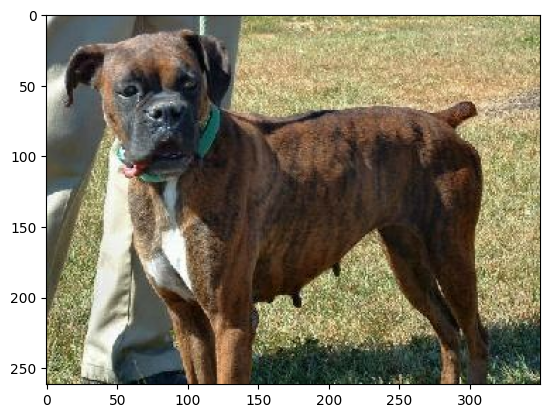

Label: 1


In [3]:
import matplotlib.pyplot as plt

for image ,label in train_ds.take(1):
  plt.imshow(image)
  plt.show()

  print("Label:", label.numpy())

In [4]:
import tensorflow as tf
IMG_SIZE=224

def preprocess(image,label):
  image=tf.image.resize(image,(224,224))
  image = image / 255.0
  return image, label

In [ ]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = tf.keras.Sequential([
  RandomFlip("horizontal_and_vertical"),
  RandomRotation(0.2),
  RandomZoom(0.2),
])

def preprocess_with_augmentation(image, label):
  image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
  image = image / 255.0
  return data_augmentation(image, training=True), label

# You would then apply this new preprocess_with_augmentation to your train_ds:
# train_ds = train_ds.map(preprocess_with_augmentation)
# test_ds = test_ds.map(preprocess)

print("Data augmentation layers created. Remember to apply them to your training dataset.")

In [5]:
train_ds = train_ds .map(preprocess)
test_ds = test_ds.map(preprocess)


In [6]:
BATCH_SIZE = 32
train_ds = train_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

In [7]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [8]:
for layers in  base_model.layers:
  layers.trainable = False

In [21]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
 30/582 ━━━━━━━━━━━━━━━━━━━━ 51:42 6s/step - accuracy: 0.6423 - loss: 0.6212

In [24]:
loss, acc = model.evaluate(test_ds)

print("Accuracy:", acc)

73/73 ━━━━━━━━━━━━━━━━━━━━ 449s 6s/step - accuracy: 0.5185 - loss: 0.8652
Accuracy: 0.5184866786003113


In [25]:
print("Model Accuracy on Test Set:", acc)

Model Accuracy on Test Set: 0.5184866786003113
